In [14]:
import numpy as np
from scipy.integrate import simpson, trapezoid
import pyccl as ccl
from tqdm import tqdm
import Function as f
from scipy.interpolate import interp1d
from astropy import units as u
from astropy import constants
import sys

Cosmological parameters redshift and the BFC parameters all into one list "par"

In [35]:
par = [0.3089,0.0486,0.8159,0.9667,0.6774,4,
           0.017,0.229,0.0074,0.0093,0.231,10**12.86,.721,5.47,1.5]

Defining the necessary functions for the PDF calculation, DM(z,M,theta) and Y(z,M,l)

In [54]:
class data_generator():
    def __init__(self,cospar):
        self.cospar = cospar
        self.Om,Ob,s8,ns = cospar[:4]
        self.h0 = cospar[4]
        self.z_frb = cospar[5]
        l_max = interp1d([.1,0.7,1.5,3,4,5],[1,1,.1,.1,.1,.1],kind='linear')
        self.l_max = l_max(self.z_frb)
        Oc = self.Om-Ob
        hmd_200c = ccl.halos.MassDef200c
        self.cosmo = ccl.Cosmology(Omega_c=Oc, Omega_b=Ob, h=self.h0, sigma8=s8, n_s=ns)
        self.mf = ccl.halos.MassFuncTinker10(mass_def=hmd_200c)  #unit Mpc^-3
        self.bm = ccl.halos.HaloBiasTinker10(mass_def=hmd_200c)
        self.z_resolution = int(10)
        self.M_resolution = int(20)
        self.l_resolution = int(1000)
        self.int_linPow = 57.5 #placeholder for the second integral in (27)

    def get_rvir(self,M_halo,z):
        '''
        Virial radious
        Inputs:
            M_halo : array-like or float
                Halo mass  (Msun/h).
            z : array-like or float
                Redshift.
        Output:
            rvir : array-like or float
                Virial radius (Mpc/h).
                Comoving
        '''
        RHOC = 2.776e11
        DELTAVIR = 200.0
        Om = self.Om
        M_halo = np.asarray(M_halo)
        z = np.asarray(z)
        rhoc_of_z = RHOC*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0
        rvir = (3.0*M_halo/(4.0*np.pi*DELTAVIR*rhoc_of_z))**(1.0/3.0)
        return rvir

    def halo_bias(self,M_halo,z):
        '''
        Halo bias function
        Inputs:
            halo mass Msun/h
            redshift
        '''
        return self.bm(self.cosmo,M_halo,1/(1+np.array(z)))

    def ang_halo_density(self,M_halo,z):
        '''
        angular halo density
        input:
        halo mass Msun/h
        redshift
        '''
        co_dist = ccl.comoving_angular_distance(self.cosmo, 1/(1+z))*self.h0 # Mpc/h
        H_z = 100*ccl.h_over_h0(self.cosmo,1/(1+z)) # h km/s/Mpc
        co_volume = co_dist**2/H_z *ccl.physical_constants.CLIGHT/1000 #Mpc^3/h^3
        halo_mass_function = self.mf(self.cosmo,M_halo/self.h0,1/(1+np.array(z))) /self.h0**3 # h^3/Mpc^3
        return co_volume*halo_mass_function 

    def vec_spec(self,par,start,end):
        '''
        Y(M,z,l) vectorization, parallel run for different mass segments (start,end)
        '''
        spectrum = np.zeros((self.z_resolution,(end-start),1000))
        redshift = np.linspace(0.0001,self.z_frb,self.z_resolution)
        mass = np.logspace(8,16,self.M_resolution)
        for i_z,z in enumerate(tqdm(redshift)):
            j = 0
            for i_M in range(start,end):
                sp = f.modelG(z,mass[i_M],self.cospar,par)
                rmax =  5*self.get_rvir(mass[i_M],z)
                dom = np.linspace(0,rmax,1000)
                y_max = np.zeros(1000)
                y_max[:998] = np.sqrt(rmax**2 - dom[:998]**2)
                y_max[999] = 0
                x3_val = np.full(1000,0)
                spectrum[i_z,j,:] = sp.frb_host.dispersion_measure_in_halo_3d(dom,-y_max,x3_val)*(1+z)
                j+=1
        np.save(f"10/spectrum.npy",spectrum)

    def Yvec(self):
        '''
        angular halo density and halo bias vectorization 
        '''
        M_min,M_max = 8,16
        z_max = self.z_frb
        M_values= np.logspace(M_min,M_max,self.M_resolution) 
        z_values= np.linspace(0.0001,z_max,self.z_resolution)
        ahd = np.zeros((self.z_resolution,self.M_resolution))
        hb = np.zeros((self.z_resolution,self.M_resolution))
        
        #vectorizing the angular halo density
        for i,z in enumerate(z_values):
            ahd[i,:] = self.ang_halo_density(M_values,z)
        np.save("10/ahd.npy", ahd)
        #vectorizing the halo bias
        for i,z in enumerate(z_values):
            hb[i,:] = self.halo_bias(M_values,z)
        np.save("10/hb.npy", hb)
            
    def Y(self,start,end):
        '''
        Y(M,z,l) vectorization, parallel run for different mass segments (start,end)'''
        data = np.load("10/spectrum.npy")
        Y = np.zeros(((end-start),self.M_resolution,self.l_resolution),dtype=complex)
        redshift = np.linspace(0.0001,self.z_frb,self.z_resolution)
        mass = np.logspace(8,16,self.M_resolution)
        l_val= np.linspace(0,1,self.l_resolution)
        l_trans = l_val**5
        l_values = l_trans*self.l_max
        l_values = l_values[None, None, :]  # Shape: (1, 1, L)
        i =0
        for i_z in tqdm(range(start,end)):
            pred = data[i_z,:,:,None]
            rmax = 5*self.get_rvir(mass,redshift[i_z])
            dom = np.linspace(0,rmax,1000)
            d_A = ccl.comoving_angular_distance(self.cosmo,1/(1+np.array(redshift[i_z])))*self.h0
            theta = np.arctan(dom.T/d_A)
            theta = theta[..., None]
            integrand = 2*np.pi* theta *(np.exp(1j*l_values* pred)-1)
            integral = simpson(integrand,x=theta, axis=1)
            Y[i,:,:] = integral
            i+=1
        np.save(f"10/Y.npy",Y)

DM(z,M,theta),
This is the most computationally expensive part of the code.

In [37]:
#par[6:]
data_generator(par).vec_spec(par[6:],0,20)

  0%|          | 0/10 [00:00<?, ?it/s]

Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise


 10%|█         | 1/10 [00:46<06:58, 46.55s/it]

Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise


 20%|██        | 2/10 [01:45<07:10, 53.78s/it]

...

Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise


 90%|█████████ | 9/10 [09:21<01:06, 66.25s/it]

Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise
Warning MACM not monotonically rising! Force monotonic rise


100%|██████████| 10/10 [10:29<00:00, 62.95s/it]

Warning MACM not monotonically rising! Force monotonic rise


In [55]:
data_generator(par).Yvec()

In [39]:
data_generator(par).Y(0,10)

100%|██████████| 10/10 [00:10<00:00,  1.07s/it]


Functions for calculating the pdf in the real space.

In [61]:
path = "10/"

class One_Point_PDF():
    def __init__(self,cospar):
        self.cospar = cospar
        Om,Ob,s8,ns = cospar[:4]
        self.h0 = cospar[4]
        self.z_frb = cospar[5]
        Oc = Om-Ob
        hmd_200c = ccl.halos.MassDef200c
        self.cosmo = ccl.Cosmology(Omega_c=Oc, Omega_b=Ob, h=self.h0, sigma8=s8, n_s=ns)
        self.mf = ccl.halos.MassFuncTinker10(mass_def=hmd_200c)  #unit Mpc^-3
        self.bm = ccl.halos.HaloBiasTinker10(mass_def=hmd_200c)
        self.z_resolution = int(10)
        self.M_resolution = int(20)
        self.l_resolution = int(1000)
        self.int_linPow = 57.5 #placeholder for the second integral in (27)

    def p(self):
        '''
        Sum over all halo masses and redshifts 
        (eq 31)
        '''
        M_min,M_max = 8,16
        z_max = self.z_frb
        M_values= np.logspace(M_min,M_max,self.M_resolution) 
        z_values= np.linspace(0.0001,z_max,self.z_resolution)
        
        Y = np.load(path+"Y.npy")
        ahd =np.load(path+"ahd.npy")
        integrand =  ahd[:,:,None]*Y
        integral_M = simpson(integrand, x=np.log10(M_values), axis=1)
        
        integral = simpson(integral_M, x=z_values, axis=0)
        
        return np.exp(integral)
    def alpha(self):
        '''
        alpha function
        (eq 35)
        Output:
            alpha : array-like
                alpha function (unitless)
        '''
        M_min,M_max = 8,16
        M_values= np.logspace(M_min,M_max,self.M_resolution) 
        
        Y = np.load(path+"Y.npy")
        ahd =np.load(path+"ahd.npy")
        hb =np.load(path+"hb.npy")
        #integral = np.zeros((self.z_resolution,self.l_resolution),dtype=complex)
        
        integrand =  hb[:,:,None]*ahd[:,:,None]*Y
        integral_M = simpson(integrand, x=np.log10(M_values), axis=1)
        return integral_M
    def growth_factor_integral(self):
        '''
        First integral (eq 47)
        '''
        z_max = self.z_frb
        z_values = np.linspace(0.0001, z_max, self.z_resolution)
        growth_factors = ccl.growth_factor(self.cosmo, 1 / (1 + z_values))
        h_values = 100 * ccl.h_over_h0(self.cosmo, 1 / (1 + z_values))
        integrand = (h_values[:, None] * self.alpha()**2 * growth_factors[:, None]**2)
        integral = simpson(integrand, x=z_values, axis=0)
        return integral
        
    def p_cl(self):
        '''
        clustered pdf from unclustered pdf
        (eq47)
        '''
        return self.p() *np.exp(1/2 * self.growth_factor_integral()*self.int_linPow/(ccl.physical_constants.CLIGHT/1000))

    ####################MEAN##########
    '''
    This part is for calculating the mean DM, which is used for the x-axis of the final PDF.
    '''

    def weight(self,z):
        Ob = self.cospar[1]
        H0 = self.h0 * 100 * u.km / u.s / u.Mpc
        m2 = 1/u.m/u.m
        prefac = 3.0*constants.c.value / \
        (constants.m_p.value*constants.G.value*8.0*np.pi) * \
        (H0.to(1/u.s)).value * \
        m2.to(u.parsec/u.cm**3).value*Ob
        f_IGM = 0.9  # keep constant for now at redshifts < 1. Can be calculated from https://github.com/FRBs/FRB/blob/main/frb/dm/igm.py as f_diffuse
        f_He = 0.24  # Helium fraction
        f_H = 1. - f_He
        f_e = (f_H + 1/2. * f_He)  # electron fraction
        result = f_e * f_IGM * prefac*(1+z)/ccl.h_over_h0(self.cosmo,1/(1+z))
        return result
    def mean(self,z):
        zval = np.linspace(0,z,1000)
        integrand = self.weight(zval)
        integral = simpson(integrand,x=zval)
        return integral
    #####################MEAN############

def final_result(cospar):
    '''
    This is the final function for calculating the PDF of DM. inverse fourier transform of p_cl (eq. 47) to get the PDF in real space.
    Output:
    ----------
    pdf: 2D array-like
        The final PDF as a function of DM.
    pcl: 2D array-like
        P_cl.
    '''
    data = One_Point_PDF(cospar).p_cl()
    d = np.linspace(0,1,1000)
    y = d**5
    l_max = interp1d([.1,.7,1.5,3,4,5],[1,1,.1,.1,.1,.1],kind='linear')
    redshift = cospar[5]
    d = y*l_max(redshift)
    firstp = np.zeros((2,1000),dtype=complex)
    firstp[0] =d    
    firstp[1] =data

    spline = interp1d(d,data,kind='linear')
    R =  np.linspace(0,l_max(redshift),100000)
    p1 = spline(R)

    plambda = np.zeros((2,100000),dtype=complex)
    plambda[0]=R
    plambda[1]=p1

    final = []
    mean = One_Point_PDF(cospar).mean(redshift)
    dom = np.linspace(0,4*mean,1000)

    for i in dom:
        integrand = p1*np.exp(-1j*R*i)
        integral = simpson(integrand,x=R)
        final.append(integral.real)
    norm_final = np.trapz(final,dom)
    final /= norm_final
    final = np.array(final)
    pdf = np.zeros((2,1000))
    pdf[0] = dom
    pdf[1] = final
    return pdf, firstp

In [62]:
pdf, pcl = final_result(par[:6])    

/home/mokka/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/mokka/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


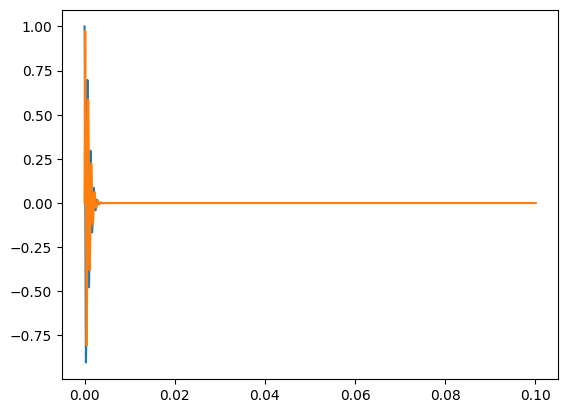

In [ ]:
import matplotlib.pyplot as plt
plt.plot(pcl[0],pcl[1].real)
plt.plot(pcl[0],pcl[1].imag)

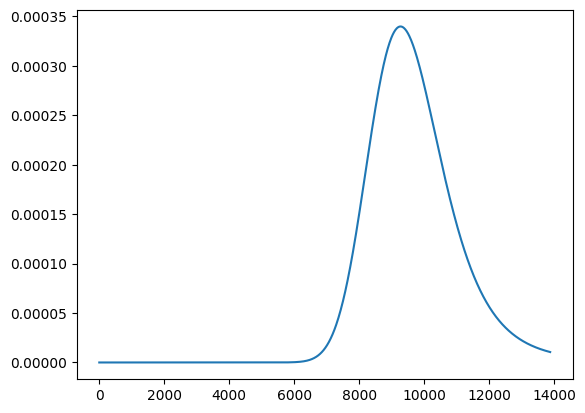

In [65]:
plt.plot(pdf[0],pdf[1])